# Recruitment Assessment Reliability Analysis

## Business Problem

CMS previously relied on externally developed recruitment assessments for hiring teachers. To reduce dependency and optimize costs, the Innovation Wing introduced internally developed assessment papers.

Management wants to evaluate whether these internally developed assessments are effective and reliable tools for assessing candidate ability.

The objective of this analysis is not only to understand candidate performance but also to evaluate the quality of the assessments in terms of difficulty, score distribution, and differentiation capability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st

import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv('/Users/air/Downloads/Master Data - Sheet1.csv')
data.head()

,S No.,Will be tested for,Name of Candidate,Marks Obtained,Maximum Marks
0,1,Senior Maths ICSE,SHUBHAM CHAUDHARI,44.0,50
1,2,Senior Maths ICSE,SHUBHAM VERMA,39.0,50
2,3,Senior Maths ICSE,DISHA KASHYAP,29.0,50
3,4,Senior Maths ICSE,AJAY KUMAR,28.0,50
4,5,Senior Maths ICSE,MANSI GANGWAR,24.0,50


# Initial Data Understanding

The dataset contains candidate-level recruitment assessment records.

Each row represents one candidate’s performance in a recruitment test.

The key columns identified are:

* Assessment category ("Will Be Tested For")
* Candidate Name
* Marks Obtained
* Maximum Marks

The analysis begins with understanding dataset structure, validating data quality, and identifying inconsistencies.


In [3]:
data.drop('S No.',axis=1,inplace=True)

# Data Understanding

In [4]:
print('Shape of the data===>',data.shape,'\n')
print('Column Information==>',data.info(),'\n')
print('Descriptive Statistics')
data.describe()

Shape of the data===> (1190, 4) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Will be tested for  1190 non-null   object 
 1   Name of Candidate   1190 non-null   object 
 2   Marks Obtained      1190 non-null   float64
 3   Maximum Marks       1190 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 37.3+ KB
Column Information==> None 

Descriptive Statistics


,Marks Obtained,Maximum Marks
count,1190.000000,1190.000000
mean,22.818067,50.500000
std,10.839116,6.793698
min,2.000000,20.000000
25%,15.000000,50.000000
50%,21.500000,50.000000
75%,29.000000,50.000000
max,94.000000,100.000000


### Findings

- The dataset contains **1,190 candidate records** 
- Variables available: candidate name, subject tested, marks obtained, and maximum marks.
- Maximum marks are not uniform across all papers, so raw score comparison would be misleading. Standardisation will be required.

# Data Quality Validation

In [5]:
print('\n Missing Values==>',data.isna().sum())
print('\n Duplicate Records==>',data.duplicated().sum())
invalid=data[data['Marks Obtained']>data['Maximum Marks']]
print('\n Records where Marks Obtained > Max Marks==>',len(invalid))


 Missing Values==> Will be tested for    0
Name of Candidate     0
Marks Obtained        0
Maximum Marks         0
dtype: int64

 Duplicate Records==> 0

 Records where Marks Obtained > Max Marks==> 0


### Findings

- No missing values were found.
- No duplicate records were identified.
- No candidate scored higher than the maximum marks.

The dataset is clean and suitable for analysis.

## Maximum Marks Consistency Check

Assessment maximum marks were reviewed to identify inconsistencies across assessments.

In [6]:
data.groupby('Will be tested for')['Maximum Marks'].unique()

Will be tested for
Art                        [20]
Commerce                   [50]
Dance                      [50]
French Teacher             [50]
ICSE Biology               [50]
ICSE Chemistry             [50]
ICSE Computer         [100, 50]
ICSE History               [50]
ICSE Maths                 [50]
ICSE Physics               [50]
ISC Accounts               [50]
ISC Biology                [50]
ISC Chemistry              [50]
ISC English                [50]
ISC History                [50]
ISC Maths                  [50]
ISC Physics                [50]
Junior English             [50]
Junior Hindi               [50]
Junior History             [50]
Junior Maths               [50]
Junior Science             [50]
Legal Studies              [50]
Music                      [85]
Physical Education         [50]
Pre-Primary                [50]
Primary Computer      [100, 50]
Primary English            [50]
Primary Maths              [50]
Robotics              [100, 50]
Senior Maths ICSE    

### Findings

A review of maximum marks revealed inconsistencies across certain assessments, where more than one maximum mark value was observed.

1. ICSE Computer
2. Primary Computer
3. Robotics

This makes direct comparison of raw scores unreliable.

To ensure fair comparison across all assessments, percentage scores were calculated and used throughout the analysis.

## Score Standardization

Percentage scores were calculated to standardize candidate performance across assessments with different maximum mark values.

In [7]:
data['Percentage']=(
    data['Marks Obtained']/
    data['Maximum Marks']
)*100

In [8]:
data.head()

,Will be tested for,Name of Candidate,Marks Obtained,Maximum Marks,Percentage
0,Senior Maths ICSE,SHUBHAM CHAUDHARI,44.0,50,88.0
1,Senior Maths ICSE,SHUBHAM VERMA,39.0,50,78.0
2,Senior Maths ICSE,DISHA KASHYAP,29.0,50,58.0
3,Senior Maths ICSE,AJAY KUMAR,28.0,50,56.0
4,Senior Maths ICSE,MANSI GANGWAR,24.0,50,48.0


### Findings

Percentage scores successfully standardized candidate performance across assessments.

This transformation allows meaningful comparison between candidates even when assessments have different maximum mark values.

All subsequent analysis was therefore performed using percentage scores rather than raw marks.

## Below is How We Will Judge Each Paper
We judge each paper on TWO things:

### Thing 1 — Difficulty
Was the paper too hard, balanced, or too easy?
We use the **Mean (average score)** to decide:

| Mean Score | Label | What it means |
|---|---|---|
| 70% or above | Easy | Most candidates did well — may be too simple |
| 45% to 70% | Moderate | Balanced — this is the sweet spot |
| Below 45% | Difficult | Most candidates struggled |

---

### Thing 2 — Reliability
Can the paper tell the difference between strong and weak candidates?
We use THREE metrics together (not just one):

| Metric | What it measures | Target |
|---|---|---|
| Std Dev | Total spread of all scores | ≥ 15 = good |
| IQR | Spread of the middle 50% of candidates | ≥ 20 = good |
| Skewness | Are scores balanced or piling up at one end? | Between –0.5 and +0.5 = good |

Each metric gets a score:
- Score 2 = good
- Score 1 = okay
- Score 0 = poor

We add all three scores together (maximum = 6).
- Total 4 to 6 → **High Reliability** — paper separates candidates well
- Total 2 to 3 → **Moderate Reliability** — some separation but limited
- Total 0 to 1 → **Low Reliability** — paper cannot tell candidates apart

**Why three metrics instead of one?**
Because Std Dev alone can be misleading.
A paper with 3 outlier candidates can have a high Std Dev even if everyone else scores in a narrow band.
IQR ignores outliers completely — it only looks at the middle 50%.
Skewness tells us if scores are balanced or lopsided.
All three together give a much more honest picture.

In [9]:
def get_difficulty(mean):
    if mean>=70:
        return 'Easy'
    elif mean>=45:
        return 'Moderate'
    else:
        return 'Difficult'

In [10]:
print("  Mean=40% →", get_difficulty(40))

  Mean=40% → Difficult


In [11]:
def get_reliability(std,iqr,skewness):
    if std>=15:
        std_score=2 #Good Spread
    elif std>=8:
        std_score=1 #Moderate
    else:
        std_score=0 #Poor Spread
        
    if iqr>=20:
        iqr_score=2 #well spread
    elif iqr>=10:
        iqr_score=1 #Moderate Spread
    else:
         iqr_score=0 #poor Spread

    # If skewness is NaN (not calculable — very small sample), give benefit of doubt = 2
    
    if np.isnan(skewness):
        skew_score=2
    elif abs(skewness)<=0.5:
        skew_score=2
    elif abs(skewness)<=1.0:
        skew_score=1
    else:
        skew_score=0
    
    total=std_score+iqr_score+skew_score
    
    if total>=4:
        return 'High',total
    elif total>=2:
        return 'Moderate',total
    else:
        return 'Low',total
#test
print("std=18,iqr=25,skew=0.1-",get_reliability(18,25,0.1))

std=18,iqr=25,skew=0.1- ('High', 6)


## Calculate All Metrics for Every Paper
Now we go through each of the 31 papers one by one.
For each paper we calculate:
Mean, Median, Mode, Std Dev, IQR, Skewness
Then apply our classification functions to get Difficulty and Reliability labels.


In [12]:
all_results=[]
for paper,group in data.groupby('Will be tested for'):
    scores=group['Percentage']
    n=len(scores)

    mean=round(scores.mean(),2)
    median=round(scores.median(),2)
    mode=round(scores.round(1).mode()[0],2)

    std=round(scores.std(),2)

    q1=scores.quantile(0.25)
    q3=scores.quantile(0.75)
    iqr=round(q3-q1,2)

    if n>=3:
        skewness=round(scores.skew(),2)
    else:
        skewness=float('nan')


    # ---Apply Functions----

    difficulty=get_difficulty(mean)
    reliability, composite = get_reliability(std,iqr,skewness)

    all_results.append({
    'Grade-Subject' : paper,
    'N'             : n,
    'Mean(%)'       : mean,
    'Median(%)'     : median,
    'Mode (%)'      : mode,
    'Std Dev'       : std,
    'IQR'           : iqr,
    'skewness'      : skewness,
    'Difficulty'    : difficulty,
    'Reliability'   : reliability,})

    summary=pd.DataFrame(all_results)
    summary = summary.sort_values('Grade-Subject').reset_index(drop=True)
    summary = summary.set_index('Grade-Subject')

print("Papers computed:", len(summary))
print("Difficulty breakdown:")
print(summary['Difficulty'].value_counts().to_string())
print()
print("Reliability breakdown:")
print(summary['Reliability'].value_counts().to_string())

Papers computed: 31
Difficulty breakdown:
Difficulty
Difficult    15
Moderate     15
Easy          1

Reliability breakdown:
Reliability
High        26
Moderate     5


In [13]:
# Select which columns you want to show in the table
columns_to_show = ['N', 'Mean(%)', 'Median(%)', 'Mode (%)',
                   'Std Dev', 'IQR', 'skewness',
                   'Difficulty', 'Reliability']


display(summary[columns_to_show])

,N,Mean(%),Median(%),Mode (%),Std Dev,IQR,skewness,Difficulty,Reliability
Grade-Subject,,,,,,,,,
Art,13,41.92,45.00,45.0,9.69,10.00,-0.56,Difficult,Moderate
Commerce,38,48.82,48.00,40.0,18.50,27.00,0.01,Moderate,High
Dance,11,38.27,34.00,10.0,27.79,45.00,0.70,Difficult,High
French Teacher,2,72.00,72.00,46.0,36.77,26.00,NaN,Easy,High
ICSE Biology,67,35.76,36.00,28.0,17.82,25.00,0.39,Difficult,High
ICSE Chemistry,37,60.76,60.00,62.0,17.09,26.00,0.02,Moderate,High
ICSE Computer,27,47.67,48.00,18.0,25.45,47.50,0.10,Moderate,High
ICSE History,17,45.94,32.00,32.0,24.18,35.00,0.66,Moderate,High
ICSE Maths,16,55.00,54.00,32.0,23.99,41.50,-0.13,Moderate,High


In [14]:
summary['Difficulty'].value_counts()

Difficulty
Difficult    15
Moderate     15
Easy          1
Name: count, dtype: int64

In [15]:
summary['Reliability'].value_counts()

Reliability
High        26
Moderate     5
Name: count, dtype: int64

### What the Summary Table Tells Us

**Difficulty**

15 papers are **Difficult** (mean below 45%):
Art, Dance, ICSE Biology, ICSE Physics, ISC Accounts, ISC Biology, ISC History, ISC Maths, ISC Physics, Junior Maths, Junior Science, Pre-Primary, Primary Computer, Primary English, Robotics

15 papers are **Moderate** (mean 45–70%):
Commerce, ICSE Chemistry, ICSE Computer, ICSE History, ICSE Maths, ISC Chemistry, ISC English, Junior English, Junior Hindi, Junior History, Legal Studies, Music, Physical Education, Primary Maths, Senior Maths ICSE

1 paper is **Easy** (mean above 70%):
French Teacher — but only 2 candidates, so this result is not reliable

**Reliability**

26 papers have **High Reliability** — they spread candidates well and can rank them
5 papers have **Moderate Reliability** — limited spread: Art, ISC English, Junior English, Junior History, Robotics
0 papers have **Low Reliability** — no paper is completely failing

# Chart 1: Mean Score by Paper

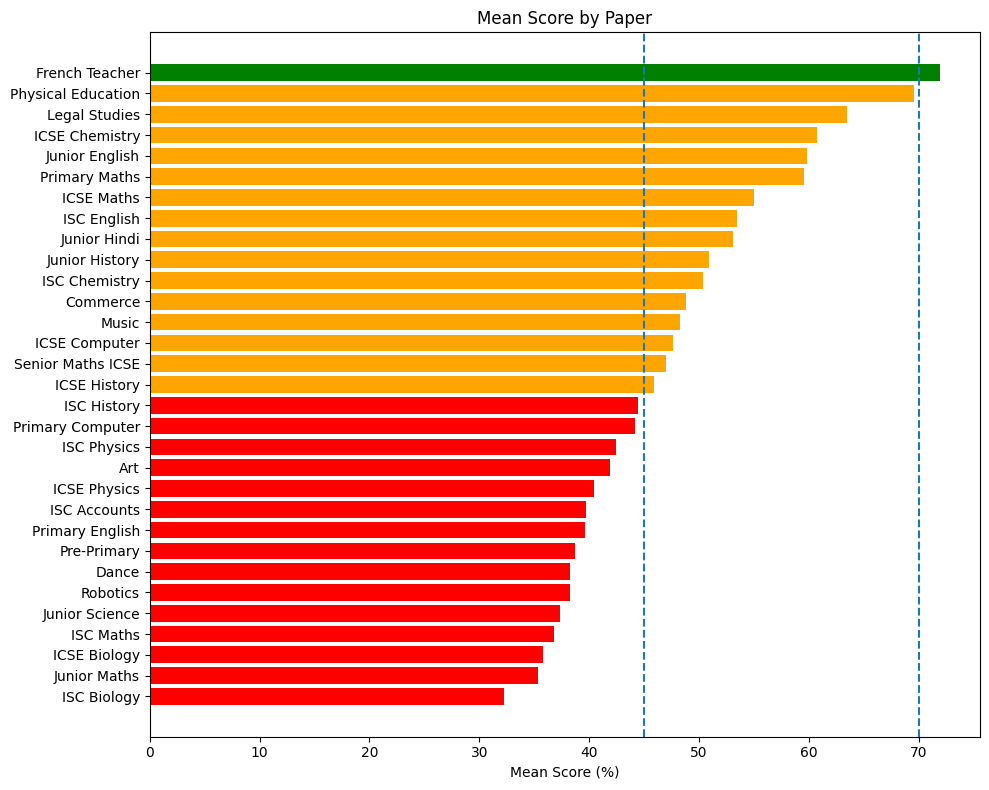

In [16]:
# Sort papers by mean score
sorted_data = summary.sort_values('Mean(%)')

# Colours
colors = {
    'Difficult': 'red',
    'Moderate': 'orange',
    'Easy': 'green'
}

bar_colors = sorted_data['Difficulty'].map(colors)

# Create chart
plt.figure(figsize=(10, 8))

plt.barh(
    sorted_data.index,
    sorted_data['Mean(%)'],
    color=bar_colors
)

# Reference lines
plt.axvline(45, linestyle='--')
plt.axvline(70, linestyle='--')

# Labels
plt.xlabel('Mean Score (%)')
plt.title('Mean Score by Paper')

plt.tight_layout()
plt.show()

### Chart 1
**15 papers (red bars) fall below the 45% line — Difficult:**
ISC Biology (32.3%), ISC Maths (36.8%), Dance (38.3%), Junior Maths (35.3%), Junior Science (37.3%), ISC Biology, Pre-Primary, Primary English, ICSE Biology, Primary Computer, Art, ICSE Physics, ISC Physics, ISC Accounts, ISC History

**15 papers (amber bars) sit between the lines — Moderate:**
Commerce, ICSE Chemistry, ICSE Computer, ICSE History, ICSE Maths, ISC Chemistry, ISC English, Junior English, Junior Hindi, Junior History, Legal Studies, Music, Physical Education, Primary Maths, Senior Maths ICSE

**1 paper (green bar) is above 70% — Easy:**
French Teacher (72%) — but only 2 candidates, treat with caution

**The overall mean line sits at 44.9%** — just below the Moderate zone, meaning the suite as a whole leans difficult

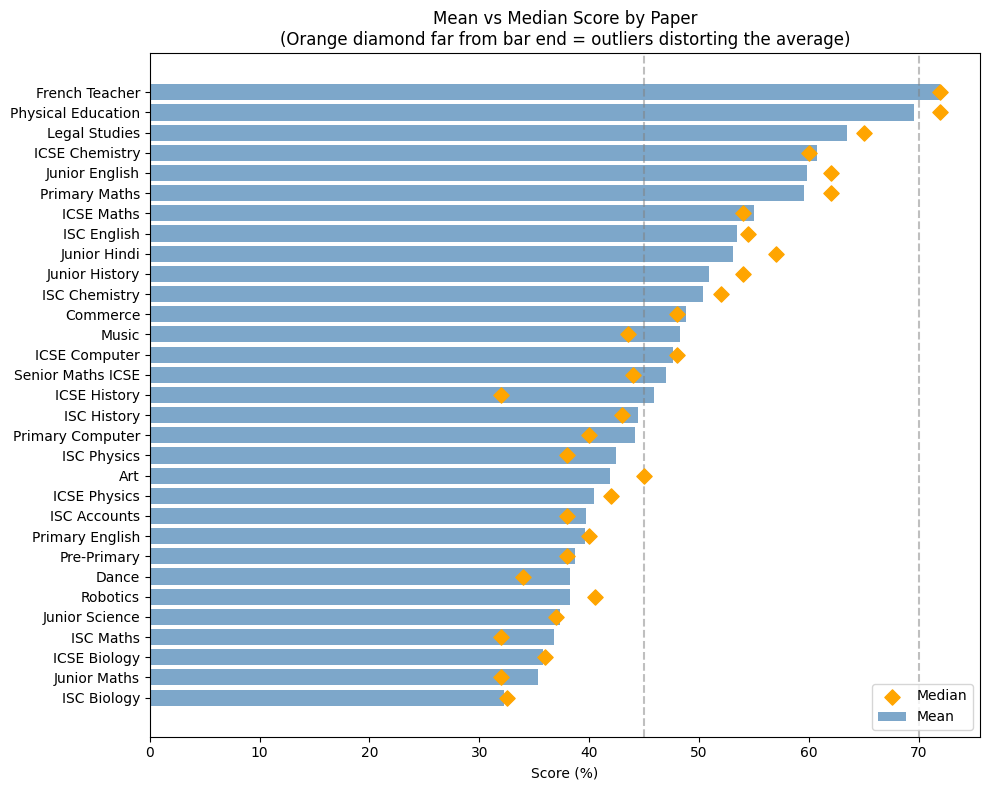

In [24]:
# Chart 1B: Mean vs Median Comparison
sorted_data = summary.sort_values('Mean(%)')

plt.figure(figsize=(10, 8))

# Mean bars (already existing logic, repeated for side-by-side)
plt.barh(sorted_data.index, sorted_data['Mean(%)'], 
         color='steelblue', alpha=0.7, label='Mean')

# Median dots overlaid
plt.scatter(sorted_data['Median(%)'], range(len(sorted_data)), 
            color='orange', zorder=5, s=60, marker='D', label='Median')

# Reference lines
plt.axvline(45, linestyle='--', color='gray', alpha=0.5)
plt.axvline(70, linestyle='--', color='gray', alpha=0.5)

plt.xlabel('Score (%)')
plt.title('Mean vs Median Score by Paper\n(Orange diamond far from bar end = outliers distorting the average)')
plt.legend()
plt.tight_layout()
plt.show()

### Chart 1B — Mean vs Median

**Why this matters:**
Mean tells us the average score. Median tells us what the middle candidate actually scored.
When the orange diamond sits far from the end of the blue bar, it means outliers are distorting the average.

**Biggest gap — ICSE History (Gap: 13.94 points):**
Mean = 45.94% but Median = 32% — the paper looks Moderate on average,
but the typical candidate scored only 32%. A few high scorers are inflating the mean.
This is the most misleading paper if mean alone is used.

**Consistent papers (Mean ≈ Median — trustworthy averages):**
French Teacher (0.0), ISC Biology (0.24), ICSE Biology (0.24), Junior Science (0.33), ICSE Computer (0.33)
These papers have no outlier distortion — the mean accurately represents candidates.

**Key Insight:**
Without the Median, ICSE History would appear to be a Moderate difficulty paper.
The Median reveals it is actually Difficult for most candidates.
This is exactly why both metrics were calculated.

# Chart 2: Score Distribution Boxplot

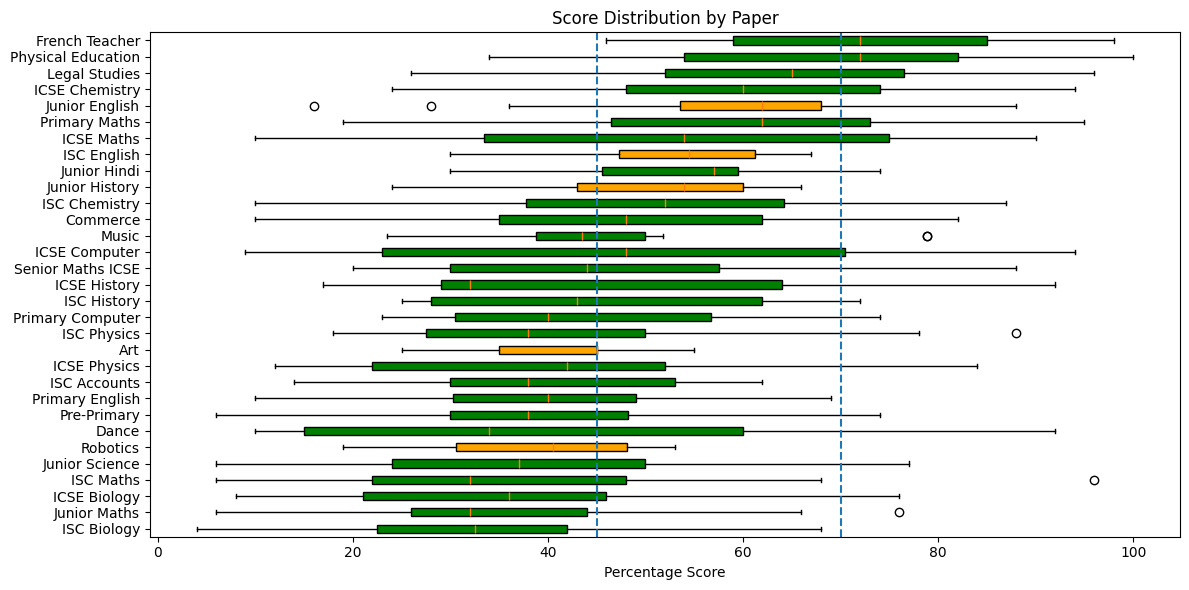

In [17]:
# Sort papers by Mean Score
paper_order = summary.sort_values('Mean(%)').index

scores = [
    data[data['Will be tested for'] == paper]['Percentage']
    for paper in paper_order
]

# Create boxplot
plt.figure(figsize=(12, 6))

box = plt.boxplot(
    scores,
    vert=False,
    patch_artist=True
)

# Colour boxes
colors = {'High': 'green', 'Moderate': 'orange', 'Low': 'red'}

for i, paper in enumerate(paper_order):
    box['boxes'][i].set_facecolor(
        colors[summary.loc[paper, 'Reliability']]
    )

# Reference lines
plt.axvline(45, linestyle='--')
plt.axvline(70, linestyle='--')

plt.yticks(range(1, len(paper_order)+1), paper_order)
plt.xlabel('Percentage Score')
plt.title('Score Distribution by Paper')

plt.tight_layout()
plt.show()

### Reading Chart 2
**Widest boxes (best differentiators — IQR shown):**
ICSE Computer (IQR=47.5), Dance (IQR=45), ICSE Maths (IQR=41.5), ICSE History (IQR=35), ICSE Physics (IQR=30)
These papers spread the middle 50% of candidates over a very wide range — excellent for ranking

**Narrowest boxes (poorest differentiators):**
Art (IQR=10), ISC English (IQR=14), Junior English (IQR=14.5), Junior Hindi (IQR=14), Junior History (IQR=17)
Candidates cluster closely together — hard to tell them apart

**Outlier dots** appear on several papers — these are individual candidates who scored far above or below everyone else

## Chart 3: Standard Deviation by Paper

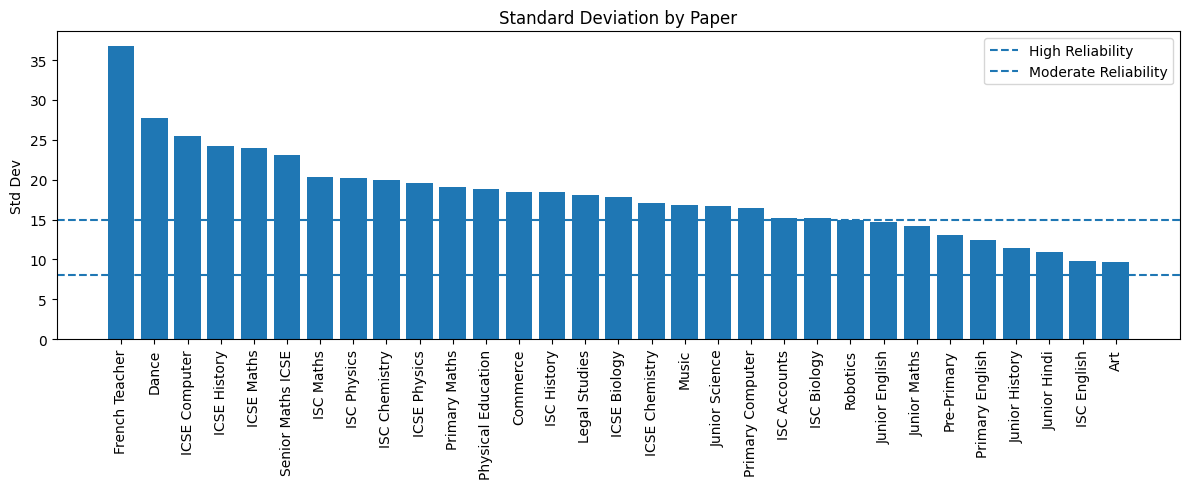

In [18]:
# Sort papers by Standard Deviation
sorted_data = summary.sort_values('Std Dev', ascending=False)

plt.figure(figsize=(12,5))

# Bar chart
plt.bar(sorted_data.index, sorted_data['Std Dev'])

# Reference lines
plt.axhline(15, linestyle='--', label='High Reliability')
plt.axhline(8, linestyle='--', label='Moderate Reliability')

# Labels
plt.title('Standard Deviation by Paper')
plt.ylabel('Std Dev')
plt.xticks(rotation=90)

plt.legend()
plt.tight_layout()
plt.show()

### Reading Chart 3
**Highest Std Dev (best differentiators):**
Dance (27.8), ICSE Computer (25.5), ISC Maths (20.4), ICSE Physics (19.6), Primary Maths (19.1)

**26 papers are above the blue line (Std Dev ≥ 15)** — the majority meet the differentiation target

**5 papers are below the blue line:**
Art (9.7), ISC English (9.8), Junior History (11.5), Junior Hindi (11.0), Junior English (14.7)
These have the most limited ability to rank candidates

**Art has the lowest Std Dev (9.7)** — candidates' scores are very tightly bunched, making ranking nearly impossible

# Chart 4: Skewness by Paper

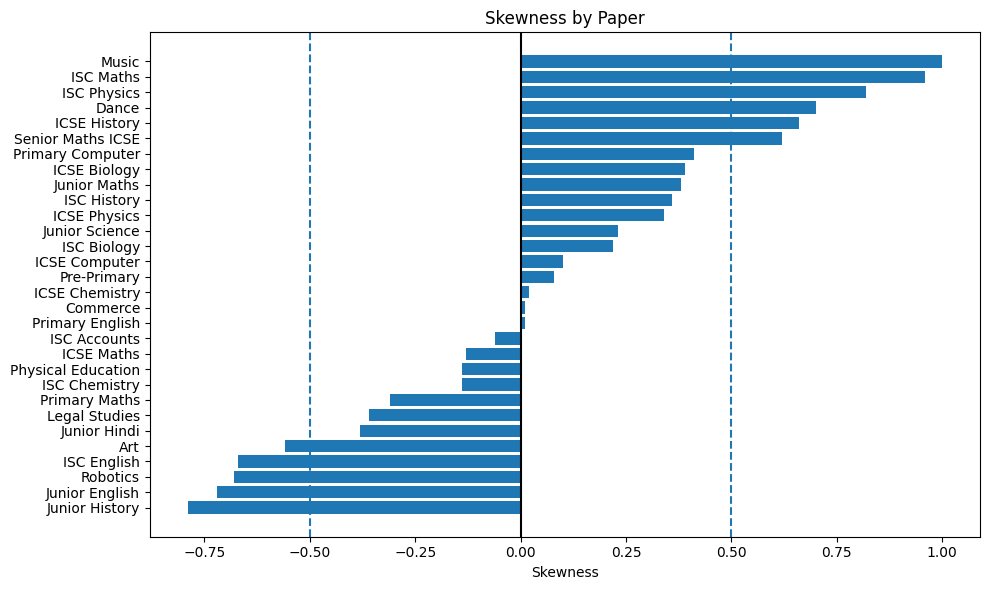

In [19]:
# Remove missing skewness values
skew_data = summary.dropna(subset=['skewness'])

# Sort by skewness
skew_data = skew_data.sort_values('skewness')

# Create chart
plt.figure(figsize=(10, 6))

plt.barh(
    skew_data.index,
    skew_data['skewness']
)

# Reference lines
plt.axvline(0, color='black')
plt.axvline(0.5, linestyle='--')
plt.axvline(-0.5, linestyle='--')

# Labels
plt.xlabel('Skewness')
plt.title('Skewness by Paper')

plt.tight_layout()
plt.show()

### Chart 4
**Most positively skewed (scores lean low — hard for most candidates):**
Music (+1.0), ISC Maths (+0.96), ISC Physics (+0.82), Dance (+0.70), ICSE History (+0.66)
Most candidates scored below the mean — a few high scorers pull the average up

**Most negatively skewed (scores lean high):**
Junior History (−0.79), Junior English (−0.72), ISC English (−0.67), Art (−0.56)
Most candidates scored above the mean — the paper may be too easy for this group

**Most balanced (between ±0.5 — good):**
Commerce (0.01), Primary English (0.01), ICSE Computer (0.10), Pre-Primary (0.08)
Scores are evenly distributed — neither too hard nor too easy for most candidates

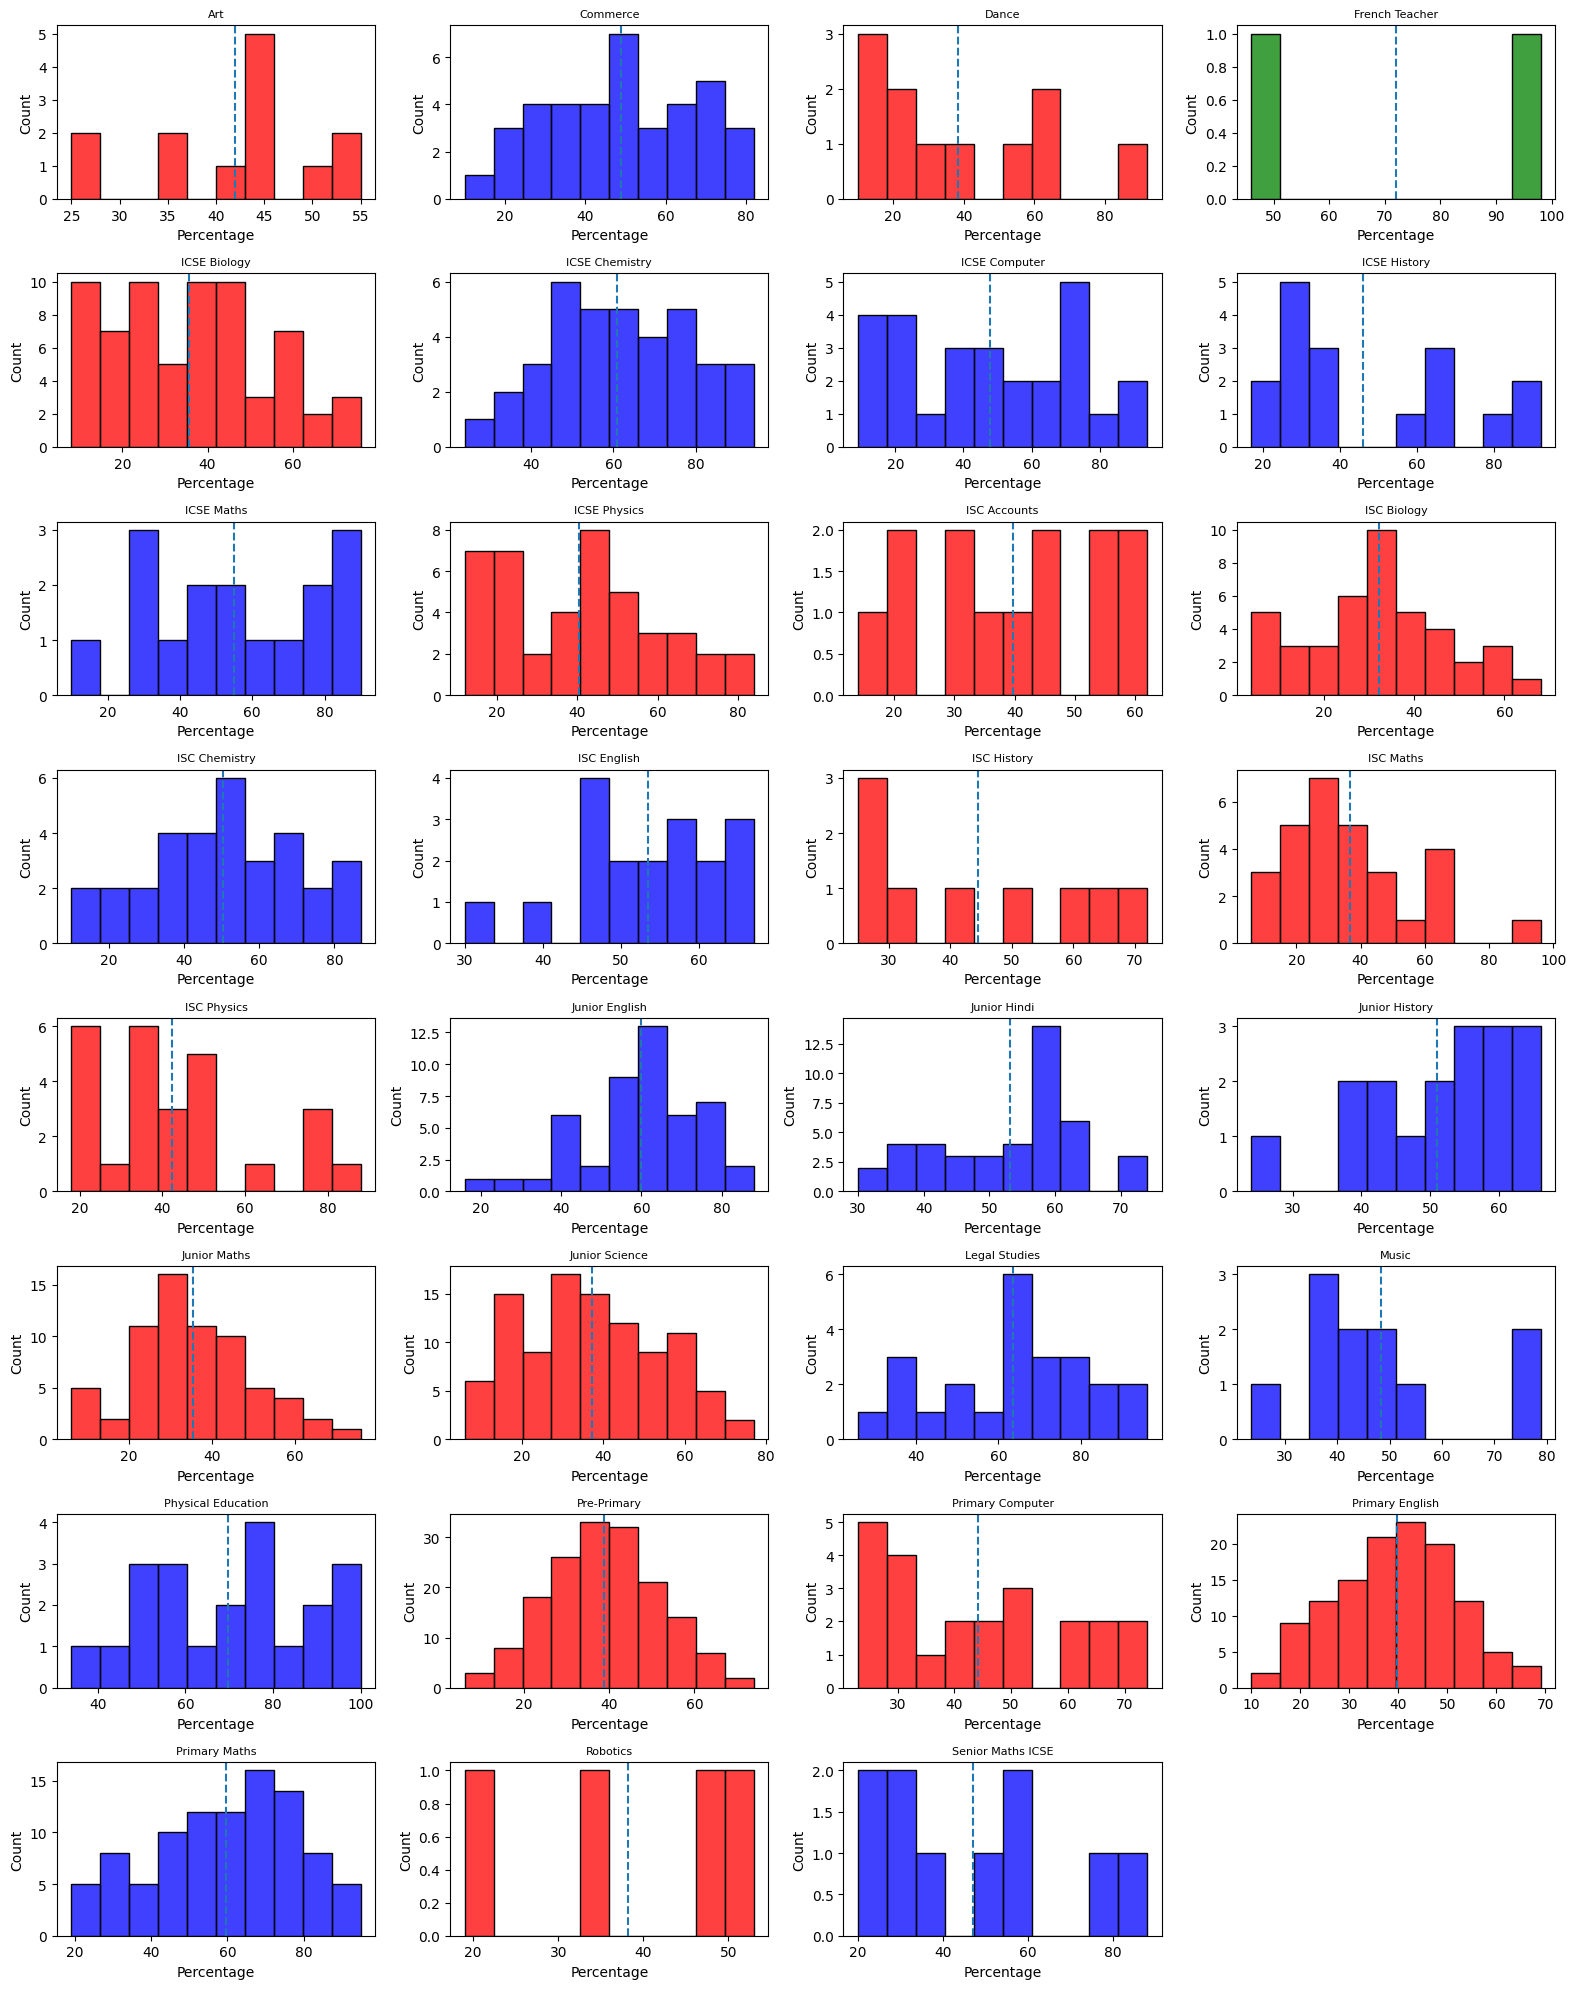

In [20]:
# Colour mapping
colors = {
    'Easy': 'green',
    'Moderate': 'blue',
    'Difficult': 'red'
}

papers = sorted(data['Will be tested for'].unique())

fig, axes = plt.subplots(8, 4, figsize=(16, 20))
axes = axes.flatten()

for i, paper in enumerate(papers):

    scores = data[data['Will be tested for'] == paper]['Percentage'

]
    difficulty = summary.loc[paper, 'Difficulty']

    sns.histplot(
        scores,
        bins=10,
        color=colors[difficulty],
        ax=axes[i]
    )

    axes[i].axvline(scores.mean(), linestyle='--')
    axes[i].set_title(paper, fontsize=8)

for j in range(len(papers), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()
plt.show()

### Reading Chart 5
**Wide, spread-out histograms (good differentiation):**
ICSE Computer, Dance, ICSE Maths, ICSE History — scores spread from very low to very high

**Narrow spikes (poor differentiation):**
Art, ISC English, Junior English, Junior History — nearly all candidates score in one tight band

**Right-skewed (hard papers — tall bars on the left):**
Junior Maths, Junior Science, ISC Biology, ICSE Biology, Pre-Primary

**Left-skewed (easier papers — tall bars on the right):**
Primary Maths, Physical Education, ISC Chemistry, Legal Studies

**⚠ Small sample papers to treat with caution:**
French Teacher (2), Robotics (4), ISC History (9), Senior Maths ICSE (10), Dance (11), Music (11)


### Paper Categorisation Matrix
This table groups all 31 papers into categories based on Difficulty + Reliability combination.

In [21]:
category_conclusions = {
    ('Difficult', 'High'):
        'Hard but effective — paper differentiates candidates well despite difficulty. Verify difficulty suits the role.',
    ('Difficult', 'Moderate'):
        'Hard with limited spread — ease a few questions to improve differentiation.',
    ('Difficult', 'Low'):
        'Critical — too hard AND fails to separate candidates. Urgent revision needed.',
    ('Moderate', 'High'):
        'Ideal papers — balanced difficulty with strong differentiation. Use as design benchmarks.',
    ('Moderate', 'Moderate'):
        'Acceptable — add more varied questions to improve candidate separation.',
    ('Moderate', 'Low'):
        'Moderate difficulty but candidates cluster — review question variety.',
    ('Easy', 'High'):
        'Accessible but functional — check if difficulty level matches the role seniority.',
    ('Easy', 'Moderate'):
        'Too easy with limited discrimination — increase challenge.',
    ('Easy', 'Low'):
        'Unusable for recruitment — all candidates score similarly.'
}

# Create empty list
rows = []

# Loop through each category
for (difficulty, reliability), conclusion in category_conclusions.items():

    papers = summary[
        (summary['Difficulty'] == difficulty) &
        (summary['Reliability'] == reliability)
    ].index.tolist()

    rows.append({
        'Category': f'{difficulty} + {reliability}',
        'Count': len(papers),
        'Papers': ', '.join(papers),
        'Conclusion': conclusion
    })

# Create DataFrame
matrix_table = pd.DataFrame(rows)

# Show table
display(matrix_table)

,Category,Count,Papers,Conclusion
0,Difficult + High,13,"Dance, ICSE Biology, ICSE Physics, ISC Account...",Hard but effective — paper differentiates cand...
1,Difficult + Moderate,2,"Art, Robotics",Hard with limited spread — ease a few question...
2,Difficult + Low,0,,Critical — too hard AND fails to separate cand...
3,Moderate + High,12,"Commerce, ICSE Chemistry, ICSE Computer, ICSE ...",Ideal papers — balanced difficulty with strong...
4,Moderate + Moderate,3,"ISC English, Junior English, Junior History",Acceptable — add more varied questions to impr...
5,Moderate + Low,0,,Moderate difficulty but candidates cluster — r...
6,Easy + High,1,French Teacher,Accessible but functional — check if difficult...
7,Easy + Moderate,0,,Too easy with limited discrimination — increas...
8,Easy + Low,0,,Unusable for recruitment — all candidates scor...


##  Executive Summary

### Are the Innovation Wing's Papers Reliable and Effective Assessment Tools?
**Overall Verdict: Mostly yes — with 5 papers needing targeted improvement.**

---

#### What the Data Shows
- 31 papers evaluated | 1,190 candidates | Overall mean 44.9%
- **26 out of 31 papers (84%) have High Reliability** — the majority successfully spread and rank candidates
- **0 papers have Low Reliability** — no paper is completely failing
- The main concern is difficulty calibration — 15 papers have a mean below 45%

#### The 11 Ideal Papers (Moderate + High Reliability)
These papers are the best-designed in the suite:
Commerce, ICSE Chemistry, ICSE Computer, ICSE History, ICSE Maths, ISC Chemistry, Junior Hindi, Legal Studies, Physical Education, Primary Maths, Senior Maths ICSE
Management should use these as design benchmarks for new papers.

#### The 13 Difficult but Effective Papers
These papers are hard but still rank candidates — they are working as recruitment tools:
ICSE Biology, ICSE Physics, ISC Accounts, ISC Biology, ISC History, ISC Maths, ISC Physics, Junior Maths, Junior Science, Pre-Primary, Primary Computer, Primary English, Dance
Management should review whether the difficulty level matches the teaching role expectations.

#### The 5 Papers Needing Revision (Moderate Reliability)
Art, ISC English, Junior English, Junior History, Robotics
These papers have limited ability to separate candidates.
Adding a wider range of question difficulty (some easier, some harder) within each paper will improve their discriminatory power.

#### Recommendations
1. Revise Art, ISC English, Junior English, Junior History — improve question variety
2. Review difficulty of the 15 Difficult papers — ensure it matches role requirements
3. Collect more candidates for small-sample papers (French Teacher, Robotics, Dance, Music)
4. Set quality targets: Mean 50–65%, Std Dev ≥ 15, IQR ≥ 20, Skewness between –0.5 and +0.5
5. Use Commerce, ICSE Chemistry, Physical Education as design templates for future papers

In [22]:
# Print the numerical verification
total = len(summary)
high_rel  = (summary['Reliability'] == 'High').sum()
mod_rel   = (summary['Reliability'] == 'Moderate').sum()
low_rel   = (summary['Reliability'] == 'Low').sum()
difficult = (summary['Difficulty']  == 'Difficult').sum()
moderate  = (summary['Difficulty']  == 'Moderate').sum()
easy      = (summary['Difficulty']  == 'Easy').sum()
small     = (summary['N'] < 15).sum()
ideal     = ((summary['Difficulty'] == 'Moderate') & (summary['Reliability'] == 'High')).sum()

print("=" * 55)
print("EXECUTIVE SUMMARY — KEY NUMBERS")
print("=" * 55)
print(f"Total papers analysed       : {total}")
print(f"Total candidates            : {len(data):,}")
print(f"Overall mean score          : {round(data['Percentage'].mean(), 2)}%")
print(f"Overall Std Dev             : {round(data['Percentage'].std(),  2)}")
print(f"Overall Skewness            : {round(data['Percentage'].skew(), 2)}")
print()
print(f"Difficult papers            : {difficult} ({round(difficult/total*100)}%)")
print(f"Moderate papers             : {moderate}  ({round(moderate/total*100)}%)")
print(f"Easy papers                 : {easy}   ({round(easy/total*100)}%)")
print()
print(f"High Reliability papers     : {high_rel} ({round(high_rel/total*100)}%)")
print(f"Moderate Reliability papers : {mod_rel}   ({round(mod_rel/total*100)}%)")
print(f"Low Reliability papers      : {low_rel}   ({round(low_rel/total*100)}%)")
print()
print(f"Ideal papers (Mod+High)     : {ideal}")
print(f"Small sample papers (<15)   : {small}")

EXECUTIVE SUMMARY — KEY NUMBERS
Total papers analysed       : 31
Total candidates            : 1,190
Overall mean score          : 44.93%
Overall Std Dev             : 19.1
Overall Skewness            : 0.32

Difficult papers            : 15 (48%)
Moderate papers             : 15  (48%)
Easy papers                 : 1   (3%)

High Reliability papers     : 26 (84%)
Moderate Reliability papers : 5   (16%)
Low Reliability papers      : 0   (0%)

Ideal papers (Mod+High)     : 12
Small sample papers (<15)   : 8


In [23]:
# Save the summary table as a CSV file for use in Tableau or Excel
summary.reset_index().to_csv('assessment_summary_for_tableau.csv', index=False)

# Save the full candidate data as well
data.to_csv('candidate_data_for_tableau.csv', index=False)

print("Two files exported:")
print("  assessment_summary_for_tableau.csv  — one row per paper, all metrics and labels")
print("  candidate_data_for_tableau.csv      — full candidate data with percentage scores")
print()
print("Use these two files as your data sources in Tableau.")

Two files exported:
  assessment_summary_for_tableau.csv  — one row per paper, all metrics and labels
  candidate_data_for_tableau.csv      — full candidate data with percentage scores

Use these two files as your data sources in Tableau.
